C:\Users\Omar\AppData\Local\Temp\ipykernel_8452\725477162.py:137: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(model_path)


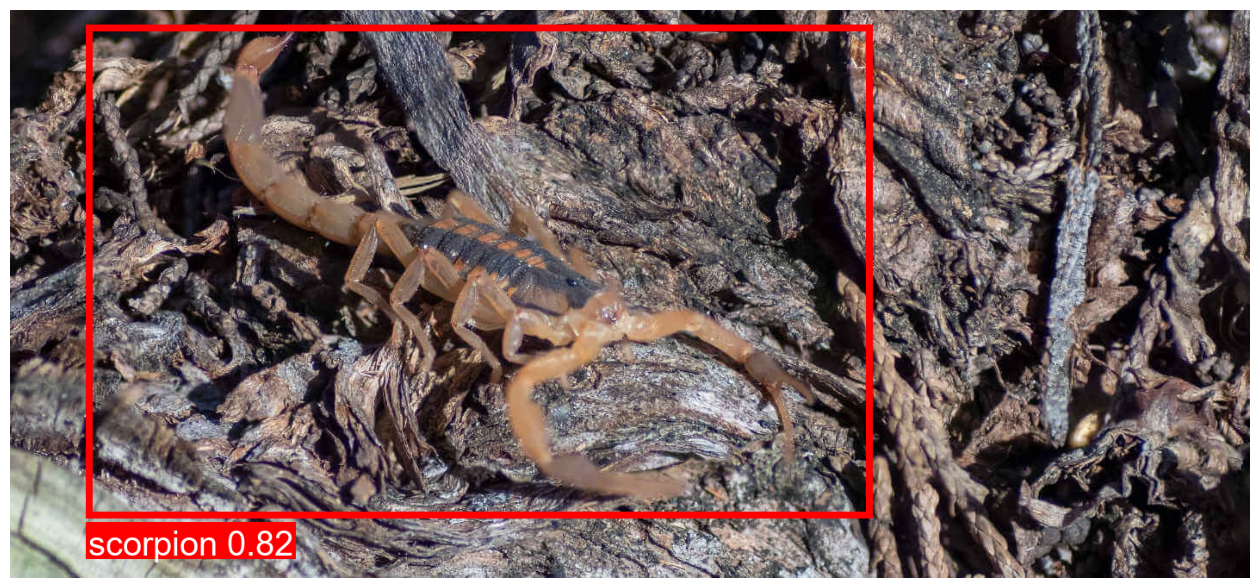

In [1]:
import torch
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torchvision.transforms as T
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

def load_model(model_path):
    
    num_classes = 2
    
    # Create a base model
    model = fasterrcnn_resnet50_fpn(pretrained=False)
    
    # Modify to match your model architecture
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    
    # Load the trained weights
    model.load_state_dict(torch.load(model_path))
    model.eval()  # Set to evaluation mode
    
    return model

def predict_image(model, image_path,  confidence_threshold=0.8):
    # Open the image
    image = Image.open(image_path).convert("RGB")
    
    # Transform the image
    transform = T.Compose([T.ToTensor()])
    img_tensor = transform(image)
    
    # Get prediction
    with torch.no_grad():
        prediction = model([img_tensor])
    
    # Get the prediction details
    boxes = prediction[0]['boxes'].cpu().numpy()
    scores = prediction[0]['scores'].cpu().numpy()
    labels = prediction[0]['labels'].cpu().numpy()
    
    # Filter based on confidence threshold
    keep = scores > confidence_threshold
    boxes = boxes[keep]
    scores = scores[keep]
    labels = labels[keep]
    
    return image, boxes, scores, labels

from PIL import ImageFont

def visualize_prediction(image, boxes, scores, labels, class_names=None):
    # Make a copy of the image
    img_draw = image.copy()
    draw = ImageDraw.Draw(img_draw)
    
    try:
        # Try to load a larger font
        font = ImageFont.truetype("arial.ttf", 40)
    except:
        # Fallback to default font
        font = ImageFont.load_default()
        print("Note: Using default font. For better results, install arial.ttf or specify an available font.")
    
    # Draw boxes
    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = box
        
        # Get label text
        if class_names and 0 <= labels[i] < len(class_names):
            label_text = class_names[labels[i]]
        else:
            label_text = f"{class_names[labels[i]-1]}"
        
        score_text = f"{scores[i]:.2f}"
        display_text = f"{label_text} {score_text}"
        
        # Draw rectangle (thicker line)
        draw.rectangle([(x1, y1), (x2, y2)], outline="red", width=8)
        
        # Calculate text size using textbbox
        text_bbox = draw.textbbox((0, 0), display_text, font=font)
        text_width = text_bbox[2] - text_bbox[0]
        text_height = text_bbox[3] - text_bbox[1]
        
#         # Draw text background ABOVE for better visibility
#         draw.rectangle(
#             [(x1, y1 - text_height - 5), 
#              (x1 + text_width + 5, y1)],
#             fill="red"
#         )
        
#         # Draw text(ABOVE) in white for better contrast
#         draw.text(
#             (x1 + 2, y1 - text_height - 3),
#             display_text,
#             fill="white",
#             font=font
#         )
        
        # Draw text background BELOW the box
        draw.rectangle(
            [(x1, y2 + 5),                     # Start at (x1, just below box)
             (x1 + text_width + 5, y2 + text_height + 10)],  # Extend to fit text
            fill="red"
        )

        # Draw text BELOW the box (with slight padding)
        draw.text(
            (x1 + 2, y2 + 7),  # y2 + 7 (just below the box + small offset)
            display_text,
            fill="white",
            font=font
        )
    
    # Display the image with larger figure size
    plt.figure(figsize=(16, 12))
    plt.imshow(img_draw)
    plt.axis('off')
    plt.show()
    
    return img_draw



# Example usage
if __name__ == "__main__":
    model_path = "fasterrcnn_resnet50_epoch_20_final.pth"
    image_path = "test-image/scorpion1.jpg"  # Replace with your image path
    
    # class names
    class_names = [
        "background", "scorpion",
    ]
    
    # Load the entire model
    model = torch.load(model_path)
    model.eval()

    
    # Run prediction
    image, boxes, scores, labels = predict_image(model, image_path)
    
    # Visualize results
    result_image = visualize_prediction(image, boxes, scores, labels, class_names)
    
    # Save the result if needed
    result_image.save("prediction_result.jpg")

In [2]:
import time
import numpy as np

# Metrics to collect
image = Image.open(image_path).convert("RGB")

# 1. Get resolution
width, height = image.size
resolution = f"{width}x{height}"

# 2. Preprocess timing
start_pre = time.time()
transform = T.Compose([T.ToTensor()])
img_tensor = transform(image)
preprocess_time = time.time() - start_pre

# 3. Inference timing
model_input = [img_tensor]
with torch.no_grad():
    start_inf = time.time()
    prediction = model(model_input)
    inference_time = time.time() - start_inf

# 4. Postprocess timing
start_post = time.time()
boxes = prediction[0]['boxes'].cpu().numpy()
scores = prediction[0]['scores'].cpu().numpy()
labels = prediction[0]['labels'].cpu().numpy()

# Apply confidence threshold
confidence_threshold = 0.8
keep = scores > confidence_threshold
boxes = boxes[keep]
scores = scores[keep]
labels = labels[keep]
postprocess_time = time.time() - start_post

# 5. Class names mapping
class_names = ["background", "scorpion"]

# 6. Print results
print(f"Image Resolution: {resolution}")
if len(labels) > 0:
    label_id = labels[0]
    label_name = class_names[label_id] if label_id < len(class_names) else f"Class {label_id}"
    print(f"Detected Class: {class_names[label_id-1]}")
    print(f"accuracy: {scores[0]:.2f}")
else:
    print("Detected Class: None")
    print("Confidence (proxy for accuracy): 0.00")
print(f"Preprocessing Time: {preprocess_time*1000:.2f} ms")
print(f"Inference Time: {inference_time*1000:.2f} ms")
print(f"Postprocessing Time: {postprocess_time*1000:.2f} ms")


Image Resolution: 1440x660
Detected Class: scorpion
accuracy: 0.82
Preprocessing Time: 6.84 ms
Inference Time: 1455.78 ms
Postprocessing Time: 1.02 ms
